In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [6]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

def extract_adaptive_features(img_path):
    # 1. Load image
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        return [0.4, 0.0, 0.0]

    # 2. CLAHE (The 'Glasses' for the computer)
    # This boosts contrast so the pupil pops out from the iris
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img_contrast = clahe.apply(img)

    # 3. Otsu's Threshold (The 'Adaptive' switch)
    # This finds the best dark/light split for this specific image
    blurred = cv2.GaussianBlur(img_contrast, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # 4. Area Math (Contour Sorting)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    pi_ratio = 0.4 # Default fallback
    if len(contours) >= 2:
        # Sort by size: Biggest is the Iris, second biggest is the Pupil
        cnts = sorted(contours, key=cv2.contourArea, reverse=True)
        iris_area = cv2.contourArea(cnts[0])
        pupil_area = cv2.contourArea(cnts[1])
        
        if iris_area > 0:
            # Square root because Area = pi * r^2
            pi_ratio = np.sqrt(pupil_area / iris_area)
            
    # Clamp crazy results (lashes or shadows)
    if pi_ratio > 0.85 or pi_ratio < 0.15:
        pi_ratio = 0.4

    # 5. Texture & Aperture (The working features)
    texture = cv2.Laplacian(img, cv2.CV_64F).var()
    v_hist = np.sum(img, axis=1)
    aperture = np.std(v_hist) / 1000.0

    return [pi_ratio, texture, aperture]

# --- EXECUTION LOOP ---
# Use your 'More Crop' RAW directory
raw_root = Path("/kaggle/input/et-cropped-dataset-second/") 
data = []

print("🔍 Starting Adaptive Extraction...")
all_images = list(raw_root.glob("*/*.jpg"))

for img_p in tqdm(all_images):
    f = extract_adaptive_features(img_p)
    data.append({
        'path': str(img_p),
        'subject': img_p.name.split('-')[0],
        'label_name': img_p.parent.name,
        'pi_ratio': f[0],
        'texture_energy': f[1],
        'aperture': f[2]
    })

# Save the new fixed data
df_adaptive = pd.DataFrame(data)
df_adaptive.to_csv("eye_features_adaptive_final_2.csv", index=False)
print("✅ Done. Check 'eye_features_adaptive_final_2.csv' for variety.")

🔍 Starting Adaptive Extraction...


100%|██████████| 4000/4000 [00:11<00:00, 348.23it/s]

✅ Done. Check 'eye_features_adaptive_final_2.csv' for variety.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import pandas as pd
import numpy as np
import os
import math
from pathlib import Path
from sklearn.model_selection import StratifiedGroupKFold

# --- 1. CORE COMPONENTS (PRESERVED) ---
class EyeballMaskLayer(layers.Layer):
    def __init__(self, radius=135, **kwargs):
        super().__init__(**kwargs)
        self.radius, self.size = radius, 300
    def build(self, input_shape):
        center = self.size // 2
        y, x = np.ogrid[:self.size, :self.size]
        mask_np = (np.sqrt((x - center)**2 + (y - center)**2) <= self.radius).astype(np.float32)
        self.mask = tf.constant(mask_np[:, :, np.newaxis], dtype=tf.float32)
        super().build(input_shape)
    def call(self, inputs): return inputs * self.mask
    def get_config(self):
        config = super().get_config()
        config.update({"radius": self.radius})
        return config

class SpatialAttention(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.conv = layers.Conv1D(1, kernel_size=3, padding='same', activation='sigmoid')
    def build(self, input_shape):
        self.conv.build((None, input_shape[1], 2)) 
        super().build(input_shape)
    def call(self, x):
        avg_p = tf.reduce_mean(x, axis=-1, keepdims=True)
        max_p = tf.reduce_max(x, axis=-1, keepdims=True)
        return x * self.conv(tf.concat([avg_p, max_p], axis=-1))

class PositionalEmbedding(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches, self.projection_dim = num_patches, projection_dim
        self.pos_emb = self.add_weight(name="pos_embedding", shape=(1, num_patches, projection_dim), initializer="zeros")
    def call(self, x): return x + self.pos_emb

class AttentionPooling(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
    def build(self, input_shape):
        self.q = self.add_weight(name="query", shape=(input_shape[-1], 1), initializer="glorot_uniform")
    def call(self, x):
        scores = tf.nn.softmax(tf.matmul(x, self.q), axis=1)
        return tf.reduce_sum(x * scores, axis=1)

class CrossAttentionBridge(layers.Layer):
    def __init__(self, num_heads=4, key_dim=32, **kwargs):
        super().__init__(**kwargs)
        self.mha = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)
    def call(self, patches, math_latent):
        q = tf.expand_dims(math_latent, axis=1) 
        attn_out = self.mha(query=q, value=patches, key=patches)
        return tf.squeeze(attn_out, axis=1)

# --- 2. DATA PIPELINE ---
def prepare_hybrid_ds(paths, math_data, labels, batch_size=16, shuffle=True):
    def parse_item(path, math_feats, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [300, 300])
        img = tf.cast(img, tf.float32) / 255.0
        return {"image_input": img, "math_input": math_feats}, \
               {"mae_output": img, "severity_output": tf.one_hot(label, 2)}

    ds = tf.data.Dataset.from_tensor_slices((paths, math_data, labels))
    if shuffle: ds = ds.shuffle(len(paths))
    return ds.map(parse_item, num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# --- FIXED ARCHITECTURE ---
def build_hybrid_model():
    img_in = layers.Input(shape=(300, 300, 3), name="image_input")
    math_in = layers.Input(shape=(3,), name="math_input")

    x = layers.BatchNormalization()(img_in)
    x = layers.RandomFlip("horizontal")(x)
    x = layers.RandomRotation(0.05)(x)
    x = EyeballMaskLayer(name="mask_layer")(x)

    # Use the same name as Phase 1
    base = tf.keras.applications.EfficientNetV2B0(include_top=False, weights=None)
    base._name = "backbone_v2"
    
    # Updated weight loading for Keras 3
    wp = "/kaggle/input/phase1-weight/anatomy_master.weights.h5"
    if os.path.exists(wp):
        # We remove by_name=True because Keras 3 does this by default
        base.load_weights(wp)
        print("✅ Phase 1 Weights Anchored.")
    else:
        print("⚠️ Weights not found at path. Check your input folder name.")

    features = base(x)
    f_h, f_w, channels = features.shape[1], features.shape[2], features.shape[3]
    
    x_seq = layers.Reshape((f_h * f_w, channels), name="transformer_reshape")(features)
    x_seq = SpatialAttention(name="seeker_layer")(x_seq)
    x_seq = PositionalEmbedding(f_h * f_w, channels, name="shared_pos_emb")(x_seq)

    # TRANSFORMER BLOCK
    res_a = x_seq
    x_seq = layers.LayerNormalization(epsilon=1e-5)(x_seq)
    x_seq = layers.MultiHeadAttention(num_heads=4, key_dim=32)(x_seq, x_seq)
    x_seq = layers.Add()([res_a, x_seq])

    # FEED FORWARD NETWORK (The missing FFN)
    res_f = x_seq
    x_seq = layers.LayerNormalization(epsilon=1e-5)(x_seq)
    x_seq = layers.Dense(channels * 2, activation='gelu', kernel_regularizer="l2")(x_seq)
    x_seq = layers.Dropout(0.5)(x_seq)
    x_seq = layers.Dense(channels)(x_seq)
    x_seq = layers.Add()([res_f, x_seq])

    # MATH ARM & CROSS ATTENTION
    m = layers.Dense(64, activation='gelu')(math_in)
    m = layers.LayerNormalization()(m)
    diag_signal = CrossAttentionBridge(name="hybrid_bridge")(x_seq, m)

    # OUTPUT HEADS
    sev = AttentionPooling()(x_seq)
    sev = layers.Concatenate()([sev, diag_signal])
    sev = layers.Dense(256, activation='gelu', kernel_regularizer="l2")(sev)
    sev = layers.Dropout(0.6)(sev)
    severity_out = layers.Dense(2, activation='softmax', name="severity_output")(sev)

    mae = layers.Reshape((f_h, f_w, channels))(x_seq)
    mae = layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(mae)
    mae = layers.UpSampling2D((2, 2))(mae)
    mae = layers.Resizing(300, 300)(mae)
    mae_out = layers.Conv2D(3, 3, padding='same', activation='sigmoid', name="mae_output")(mae)

    return models.Model(inputs=[img_in, math_in], 
                        outputs={"mae_output": mae_out, "severity_output": severity_out}), base
# --- 4. EXECUTION ---
# --- REVISED PATH FIX ---
# Load the CSV
df = pd.read_csv('/kaggle/input/eye-features-adaptive-final/eye_features_adaptive_final_2.csv')

# Use this logic to build a fresh, absolute path for every image
def fix_kaggle_path(row):
    filename = row['path'].split('/')[-1] # Gets '23-210-high-re.jpg'
    label = row['label_name']             # Gets 'high'
    # Rebuild: /kaggle/input/et-autism-dataset/label/label/filename
    return f"/kaggle/input/et-cropped-dataset-second/{label}/{filename}"

df['path'] = df.apply(fix_kaggle_path, axis=1)

# Verify the first path before training
print(f"DEBUG: Checking path: {df['path'].iloc[0]}")
if not os.path.exists(df['path'].iloc[0]):
    print("❌ ERROR: Path still not found. Check if the dataset name is 'et-autism-dataset'")
else:
    print("✅ SUCCESS: Path is valid. Training can start.")

# Rename columns to match your model heads
df = df.rename(columns={'texture_energy': 'texture', 'label_name': 'label'})



class_map = {'mild': 0, 'low': 0, 'medium': 1, 'high': 1}
df['label_num'] = df['label'].map(class_map)
math_feats = df[['pi_ratio', 'texture', 'aperture']].values

sgkf = StratifiedGroupKFold(n_splits=2, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(sgkf.split(df.path, df.label_num, groups=df.subject)):
    print(f"\n🚀 STARTING HYBRID SIGNAL TEST - FOLD {fold+1}")
    train_ds = prepare_hybrid_ds(df.iloc[train_idx].path, math_feats[train_idx], df.iloc[train_idx].label_num)
    val_ds = prepare_hybrid_ds(df.iloc[val_idx].path, math_feats[val_idx], df.iloc[val_idx].label_num, shuffle=False)
    
    model, backbone = build_hybrid_model()
    backbone.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss={"mae_output": "mse", "severity_output": "categorical_crossentropy"},
        loss_weights={"mae_output": 0.05, "severity_output": 2.0},
        metrics={"severity_output": ["accuracy", tf.keras.metrics.AUC(name='auc')]}
    )
    
    model.fit(train_ds, validation_data=val_ds, epochs=15)

    # UNFREEZE BACKBONE
    backbone.trainable = True
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-6), 
                  loss={"mae_output": "mse", "severity_output": "categorical_crossentropy"},
                  loss_weights={"mae_output": 0.05, "severity_output": 2.0},
                  metrics={"severity_output": ["accuracy"]})
    model.fit(train_ds, validation_data=val_ds, epochs=10)

2026-01-28 09:41:59.064988: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769593319.273131      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769593319.331062      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769593319.788547      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769593319.788587      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769593319.788590      55 computation_placer.cc:177] computation placer alr

DEBUG: Checking path: /kaggle/input/et-cropped-dataset-second/mild/44-50-mild-le.jpg
✅ SUCCESS: Path is valid. Training can start.

🚀 STARTING HYBRID SIGNAL TEST - FOLD 1


I0000 00:00:1769593333.067235      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1769593333.071085      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


✅ Phase 1 Weights Anchored.
Epoch 1/15


E0000 00:00:1769593353.015295      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1769593357.110605     126 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1769593357.657207     126 cuda_solvers.cc:175] Creating GpuSolver handles for stream 0x23825b20


125/125 ━━━━━━━━━━━━━━━━━━━━ 65s 333ms/step - loss: 22.2998 - mae_output_loss: 0.0406 - severity_output_accuracy: 0.5669 - severity_output_auc: 0.5947 - severity_output_loss: 0.8048 - val_loss: 20.4766 - val_mae_output_loss: 0.0184 - val_severity_output_accuracy: 0.4555 - val_severity_output_auc: 0.4442 - val_severity_output_loss: 0.8577
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 40s 319ms/step - loss: 19.4499 - mae_output_loss: 0.0212 - severity_output_accuracy: 0.6196 - severity_output_auc: 0.6790 - severity_output_loss: 0.6575 - val_loss: 19.3347 - val_mae_output_loss: 0.0130 - val_severity_output_accuracy: 0.4620 - val_severity_output_auc: 0.4610 - val_severity_output_loss: 1.5096
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 330ms/step - loss: 17.0234 - mae_output_loss: 0.0187 - severity_output_accuracy: 0.6696 - severity_output_auc: 0.7141 - severity_output_loss: 0.6291 - val_loss: 16.4987 - val_mae_output_loss: 0.0105 - val_severity_output_accuracy: 0.4990 - val_severity_output_auc: 

E0000 00:00:1769594027.235818      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


125/125 ━━━━━━━━━━━━━━━━━━━━ 110s 485ms/step - loss: 4.3660 - mae_output_loss: 0.0381 - severity_output_accuracy: 0.6197 - severity_output_loss: 0.6422 - val_loss: 4.7219 - val_mae_output_loss: 0.0263 - val_severity_output_accuracy: 0.4920 - val_severity_output_loss: 0.8227
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 56s 452ms/step - loss: 4.3224 - mae_output_loss: 0.0331 - severity_output_accuracy: 0.6271 - severity_output_loss: 0.6236 - val_loss: 4.6978 - val_mae_output_loss: 0.0229 - val_severity_output_accuracy: 0.5085 - val_severity_output_loss: 0.8138
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 57s 453ms/step - loss: 4.2841 - mae_output_loss: 0.0308 - severity_output_accuracy: 0.6306 - severity_output_loss: 0.6074 - val_loss: 4.6658 - val_mae_output_loss: 0.0208 - val_severity_output_accuracy: 0.5015 - val_severity_output_loss: 0.8008
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 56s 452ms/step - loss: 4.2554 - mae_output_loss: 0.0284 - severity_output_accuracy: 0.6557 - severity_output_loss: 

E0000 00:00:1769594621.701193      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


125/125 ━━━━━━━━━━━━━━━━━━━━ 65s 368ms/step - loss: 22.3019 - mae_output_loss: 0.0353 - severity_output_accuracy: 0.5253 - severity_output_auc: 0.5487 - severity_output_loss: 0.8055 - val_loss: 21.1023 - val_mae_output_loss: 0.0228 - val_severity_output_accuracy: 0.4300 - val_severity_output_auc: 0.4523 - val_severity_output_loss: 1.2859
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 42s 336ms/step - loss: 19.0498 - mae_output_loss: 0.0191 - severity_output_accuracy: 0.7027 - severity_output_auc: 0.7701 - severity_output_loss: 0.5881 - val_loss: 18.1788 - val_mae_output_loss: 0.0166 - val_severity_output_accuracy: 0.4335 - val_severity_output_auc: 0.4258 - val_severity_output_loss: 1.0809
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 42s 336ms/step - loss: 16.6214 - mae_output_loss: 0.0169 - severity_output_accuracy: 0.7097 - severity_output_auc: 0.7713 - severity_output_loss: 0.5837 - val_loss: 15.8541 - val_mae_output_loss: 0.0123 - val_severity_output_accuracy: 0.4680 - val_severity_output_auc: 

2026-01-28 10:13:52.070340: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769595232.261903      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769595232.316288      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769595232.784966      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769595232.785003      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769595232.785006      55 computation_placer.cc:177] computation placer alr

DEBUG: Checking path: /kaggle/input/et-cropped-dataset-second/mild/44-50-mild-le.jpg
✅ SUCCESS: Path valid.

🚀 STARTING SINGLE HYBRID SIGNAL TEST


I0000 00:00:1769595246.461066      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1769595246.464943      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


✅ Phase 1 Weights Anchored.
Epoch 1/15


E0000 00:00:1769595266.223811      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1769595270.099118     121 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1769595270.662751     121 cuda_solvers.cc:175] Creating GpuSolver handles for stream 0x3b368030


200/200 ━━━━━━━━━━━━━━━━━━━━ 75s 260ms/step - loss: 21.8407 - mae_output_loss: 0.0307 - severity_output_accuracy: 0.5393 - severity_output_auc: 0.5689 - severity_output_loss: 0.7885 - val_loss: 18.5155 - val_mae_output_loss: 0.0234 - val_severity_output_accuracy: 0.5475 - val_severity_output_auc: 0.5875 - val_severity_output_loss: 0.6814
Epoch 2/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 51s 253ms/step - loss: 17.5671 - mae_output_loss: 0.0181 - severity_output_accuracy: 0.6049 - severity_output_auc: 0.6504 - severity_output_loss: 0.6687 - val_loss: 15.1778 - val_mae_output_loss: 0.0165 - val_severity_output_accuracy: 0.5050 - val_severity_output_auc: 0.5538 - val_severity_output_loss: 0.7578
Epoch 3/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 53s 264ms/step - loss: 14.1620 - mae_output_loss: 0.0158 - severity_output_accuracy: 0.6795 - severity_output_auc: 0.7331 - severity_output_loss: 0.6167 - val_loss: 12.3232 - val_mae_output_loss: 0.0140 - val_severity_output_accuracy: 0.5100 - val_severity_output_auc: 

E0000 00:00:1769596105.879537      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


200/200 ━━━━━━━━━━━━━━━━━━━━ 128s 404ms/step - loss: 2.3311 - mae_output_loss: 0.0393 - severity_output_accuracy: 0.5936 - severity_output_loss: 0.6634 - val_loss: 2.6210 - val_mae_output_loss: 0.0424 - val_severity_output_accuracy: 0.4712 - val_severity_output_loss: 0.8093
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 77s 386ms/step - loss: 2.2421 - mae_output_loss: 0.0324 - severity_output_accuracy: 0.6489 - severity_output_loss: 0.6205 - val_loss: 2.5478 - val_mae_output_loss: 0.0369 - val_severity_output_accuracy: 0.5113 - val_severity_output_loss: 0.7742
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 77s 386ms/step - loss: 2.2140 - mae_output_loss: 0.0276 - severity_output_accuracy: 0.6626 - severity_output_loss: 0.6079 - val_loss: 2.5588 - val_mae_output_loss: 0.0300 - val_severity_output_accuracy: 0.5275 - val_severity_output_loss: 0.7813
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 77s 386ms/step - loss: 2.1404 - mae_output_loss: 0.0244 - severity_output_accuracy: 0.6993 - severity_output_loss: 

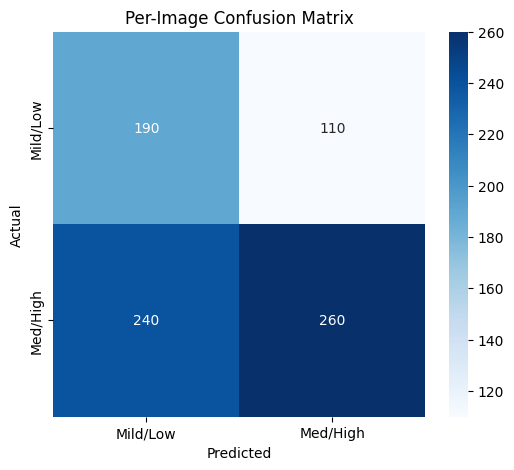


🔥 FINAL SUBJECT-LEVEL ACCURACY: 62.50%

Classification Report (Per Image):
              precision    recall  f1-score   support

    Mild/Low       0.44      0.63      0.52       300
    Med/High       0.70      0.52      0.60       500

    accuracy                           0.56       800
   macro avg       0.57      0.58      0.56       800
weighted avg       0.60      0.56      0.57       800



In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import pandas as pd
import numpy as np
import os
import math
from pathlib import Path
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. CORE COMPONENTS (PRESERVED) ---
class EyeballMaskLayer(layers.Layer):
    def __init__(self, radius=135, **kwargs):
        super().__init__(**kwargs)
        self.radius, self.size = radius, 300
    def build(self, input_shape):
        center = self.size // 2
        y, x = np.ogrid[:self.size, :self.size]
        mask_np = (np.sqrt((x - center)**2 + (y - center)**2) <= self.radius).astype(np.float32)
        self.mask = tf.constant(mask_np[:, :, np.newaxis], dtype=tf.float32)
        super().build(input_shape)
    def call(self, inputs): return inputs * self.mask
    def get_config(self):
        config = super().get_config()
        config.update({"radius": self.radius})
        return config

class SpatialAttention(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.conv = layers.Conv1D(1, kernel_size=3, padding='same', activation='sigmoid')
    def build(self, input_shape):
        self.conv.build((None, input_shape[1], 2)) 
        super().build(input_shape)
    def call(self, x):
        avg_p = tf.reduce_mean(x, axis=-1, keepdims=True)
        max_p = tf.reduce_max(x, axis=-1, keepdims=True)
        return x * self.conv(tf.concat([avg_p, max_p], axis=-1))

class PositionalEmbedding(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches, self.projection_dim = num_patches, projection_dim
        self.pos_emb = self.add_weight(name="pos_embedding", shape=(1, num_patches, projection_dim), initializer="zeros")
    def call(self, x): return x + self.pos_emb

class AttentionPooling(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
    def build(self, input_shape):
        self.q = self.add_weight(name="query", shape=(input_shape[-1], 1), initializer="glorot_uniform")
    def call(self, x):
        scores = tf.nn.softmax(tf.matmul(x, self.q), axis=1)
        return tf.reduce_sum(x * scores, axis=1)

class CrossAttentionBridge(layers.Layer):
    def __init__(self, num_heads=4, key_dim=32, **kwargs):
        super().__init__(**kwargs)
        self.mha = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)
    def call(self, patches, math_latent):
        q = tf.expand_dims(math_latent, axis=1) 
        attn_out = self.mha(query=q, value=patches, key=patches)
        return tf.squeeze(attn_out, axis=1)

# --- 2. DATA PIPELINE ---
def prepare_hybrid_ds(paths, math_data, labels, batch_size=16, shuffle=True):
    def parse_item(path, math_feats, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [300, 300])
        img = tf.cast(img, tf.float32) / 255.0
        return {"image_input": img, "math_input": math_feats}, \
               {"mae_output": img, "severity_output": tf.one_hot(label, 2)}

    ds = tf.data.Dataset.from_tensor_slices((paths, math_data, labels))
    if shuffle: ds = ds.shuffle(len(paths))
    return ds.map(parse_item, num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# --- 3. ARCHITECTURE ---
def build_hybrid_model():
    img_in = layers.Input(shape=(300, 300, 3), name="image_input")
    math_in = layers.Input(shape=(3,), name="math_input")

    x = layers.BatchNormalization()(img_in)
    x = layers.RandomFlip("horizontal")(x)
    x = layers.RandomRotation(0.05)(x)
    x = EyeballMaskLayer(name="mask_layer")(x)

    base = tf.keras.applications.EfficientNetV2B0(include_top=False, weights=None)
    base._name = "backbone_v2"
    
    wp = "/kaggle/input/phase1-weight/anatomy_master.weights.h5"
    if os.path.exists(wp):
        base.load_weights(wp)
        print("✅ Phase 1 Weights Anchored.")
    else:
        print("⚠️ Weights not found at path.")

    features = base(x)
    f_h, f_w, channels = features.shape[1], features.shape[2], features.shape[3]
    
    x_seq = layers.Reshape((f_h * f_w, channels), name="transformer_reshape")(features)
    x_seq = SpatialAttention(name="seeker_layer")(x_seq)
    x_seq = PositionalEmbedding(f_h * f_w, channels, name="shared_pos_emb")(x_seq)

    res_a = x_seq
    x_seq = layers.LayerNormalization(epsilon=1e-5)(x_seq)
    x_seq = layers.MultiHeadAttention(num_heads=4, key_dim=32)(x_seq, x_seq)
    x_seq = layers.Add()([res_a, x_seq])

    res_f = x_seq
    x_seq = layers.LayerNormalization(epsilon=1e-5)(x_seq)
    x_seq = layers.Dense(channels * 2, activation='gelu', kernel_regularizer="l2")(x_seq)
    x_seq = layers.Dropout(0.5)(x_seq)
    x_seq = layers.Dense(channels)(x_seq)
    x_seq = layers.Add()([res_f, x_seq])

    m = layers.Dense(64, activation='gelu')(math_in)
    m = layers.LayerNormalization()(m)
    diag_signal = CrossAttentionBridge(name="hybrid_bridge")(x_seq, m)

    sev = AttentionPooling()(x_seq)
    sev = layers.Concatenate()([sev, diag_signal])
    sev = layers.Dense(256, activation='gelu', kernel_regularizer="l2")(sev)
    sev = layers.Dropout(0.6)(sev)
    severity_out = layers.Dense(2, activation='softmax', name="severity_output")(sev)

    mae = layers.Reshape((f_h, f_w, channels))(x_seq)
    mae = layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(mae)
    mae = layers.UpSampling2D((2, 2))(mae)
    mae = layers.Resizing(300, 300)(mae)
    mae_out = layers.Conv2D(3, 3, padding='same', activation='sigmoid', name="mae_output")(mae)

    return models.Model(inputs=[img_in, math_in], 
                        outputs={"mae_output": mae_out, "severity_output": severity_out}), base

# --- 4. EXECUTION ---
df = pd.read_csv('/kaggle/input/eye-features-adaptive-final/eye_features_adaptive_final_2.csv')

def fix_kaggle_path(row):
    filename = row['path'].split('/')[-1]
    label = row['label_name']
    return f"/kaggle/input/et-cropped-dataset-second/{label}/{filename}"

df['path'] = df.apply(fix_kaggle_path, axis=1)

# Debug check
print(f"DEBUG: Checking path: {df['path'].iloc[0]}")
if not os.path.exists(df['path'].iloc[0]):
    print("❌ ERROR: Path not found.")
else:
    print("✅ SUCCESS: Path valid.")

df = df.rename(columns={'texture_energy': 'texture', 'label_name': 'label'})
class_map = {'mild': 0, 'low': 0, 'medium': 1, 'high': 1}
df['label_num'] = df['label'].map(class_map)
math_feats = df[['pi_ratio', 'texture', 'aperture']].values

# --- MODIFIED: ONE SPLIT LOGIC ---
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, val_idx = next(sgkf.split(df.path, df.label_num, groups=df.subject))

print(f"\n🚀 STARTING SINGLE HYBRID SIGNAL TEST")
train_ds = prepare_hybrid_ds(df.iloc[train_idx].path, math_feats[train_idx], df.iloc[train_idx].label_num)
val_ds = prepare_hybrid_ds(df.iloc[val_idx].path, math_feats[val_idx], df.iloc[val_idx].label_num, shuffle=False)

model, backbone = build_hybrid_model()
backbone.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss={"mae_output": "mse", "severity_output": "categorical_crossentropy"},
    loss_weights={"mae_output": 0.05, "severity_output": 2.0},
    metrics={"severity_output": ["accuracy", tf.keras.metrics.AUC(name='auc')]}
)

model.fit(train_ds, validation_data=val_ds, epochs=15)

backbone.trainable = True
model.compile(optimizer=tf.keras.optimizers.Adam(1e-6), 
              loss={"mae_output": "mse", "severity_output": "categorical_crossentropy"},
              loss_weights={"mae_output": 0.05, "severity_output": 2.0},
              metrics={"severity_output": ["accuracy"]})
model.fit(train_ds, validation_data=val_ds, epochs=10)

# --- 5. NEW: FINAL ANALYSIS (CONFUSION MATRIX & SUBJECT ACCURACY) ---
print("\n📊 RUNNING FINAL ANALYSIS...")
preds = model.predict(val_ds)
y_pred = np.argmax(preds['severity_output'], axis=1)
y_true = df.iloc[val_idx].label_num.values

# Per-Image Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Mild/Low', 'Med/High'], yticklabels=['Mild/Low', 'Med/High'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Per-Image Confusion Matrix')
plt.show()

# Subject-Level Consensus Accuracy
val_results = df.iloc[val_idx].copy()
val_results['pred_label'] = y_pred

subject_vote = val_results.groupby('subject').agg({
    'label_num': 'first',
    'pred_label': lambda x: x.value_counts().index[0] # Majority vote
})

subject_acc = (subject_vote['label_num'] == subject_vote['pred_label']).mean()
print(f"\n🔥 FINAL SUBJECT-LEVEL ACCURACY: {subject_acc*100:.2f}%")
print("\nClassification Report (Per Image):")
print(classification_report(y_true, y_pred, target_names=['Mild/Low', 'Med/High']))

In [1]:
import cv2
import os
import shutil
import pandas as pd
from tqdm import tqdm

# --- KAGGLE PATHS ---
input_root = "/kaggle/input/et-cropped-dataset-second"
output_sharp = "/kaggle/working/sharp_dataset"
output_blurry = "/kaggle/working/blurry_dataset"

# Labels from your dataset outline
labels = ['high', 'low', 'medium', 'mild']

def get_blur_score(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None: return -1
    return cv2.Laplacian(img, cv2.CV_64F).var()

# 1. Collect every image path and its score
print("🔍 Calculating sharpness for all 4000 images...")
data = []
for label in labels:
    label_path = os.path.join(input_root, label)
    if not os.path.exists(label_path): continue
    
    for file in os.listdir(label_path):
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            full_path = os.path.join(label_path, file)
            score = get_blur_score(full_path)
            if score != -1:
                data.append({'path': full_path, 'label': label, 'score': score, 'name': file})

# 2. Sort globally by score
df = pd.DataFrame(data)
df = df.sort_values('score').reset_index(drop=True)

# 3. Define the bottom 1000 as blurry
cutoff = 1000
blurry_df = df.iloc[:cutoff]
sharp_df = df.iloc[cutoff:]

print(f"✅ Cutoff score: {df.iloc[cutoff]['score']:.2f}")
print(f"📦 Moving {len(blurry_df)} to Blurry and {len(sharp_df)} to Sharp...")

# 4. Move files and keep folder structure
for target_root, subset_df in [(output_blurry, blurry_df), (output_sharp, sharp_df)]:
    for _, row in tqdm(subset_df.iterrows(), total=len(subset_df)):
        # Create the subfolder (e.g., sharp_dataset/high/)
        dest_dir = os.path.join(target_root, row['label'])
        os.makedirs(dest_dir, exist_ok=True)
        # Copy the file
        shutil.copy(row['path'], os.path.join(dest_dir, row['name']))

print(f"\n🎉 Done. Your clean dataset is in: {output_sharp}")

🔍 Calculating sharpness for all 4000 images...
✅ Cutoff score: 2.92
📦 Moving 1000 to Blurry and 3000 to Sharp...


100%|██████████| 3000/3000 [00:04<00:00, 656.90it/s]


🎉 Done. Your clean dataset is in: /kaggle/working/sharp_dataset


2026-01-28 10:58:31.875871: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769597912.055291      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769597912.108255      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769597912.554660      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769597912.554712      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769597912.554717      55 computation_placer.cc:177] computation placer alr

✅ Clean Dataset: 3000 images surviving.


I0000 00:00:1769597925.453160      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1769597925.456991      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
🚀 Starting Single-Split Training...
Epoch 1/30


E0000 00:00:1769597964.261064      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1769597970.520206     124 cuda_dnn.cc:529] Loaded cuDNN version 91002


152/152 ━━━━━━━━━━━━━━━━━━━━ 87s 278ms/step - accuracy: 0.5199 - loss: 0.7049 - val_accuracy: 0.5764 - val_loss: 0.6920
Epoch 2/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 39s 255ms/step - accuracy: 0.6460 - loss: 0.6120 - val_accuracy: 0.5237 - val_loss: 0.6828
Epoch 3/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 40s 265ms/step - accuracy: 0.6617 - loss: 0.5874 - val_accuracy: 0.5202 - val_loss: 0.7463
Epoch 4/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 41s 267ms/step - accuracy: 0.7164 - loss: 0.5254 - val_accuracy: 0.5624 - val_loss: 0.6999
Epoch 5/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 40s 265ms/step - accuracy: 0.7603 - loss: 0.4751 - val_accuracy: 0.5800 - val_loss: 0.6736
Epoch 6/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 40s 266ms/step - accuracy: 0.7987 - loss: 0.4178 - val_accuracy: 0.5483 - val_loss: 1.2524
Epoch 7/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 40s 265ms/step - accuracy: 0.7929 - loss: 0.4281 - val_accuracy: 0.5132 - val_loss: 1.2881
Epoch 8/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 40s 266ms/step - accuracy: 0.8105 - loss: 0.3826 - val

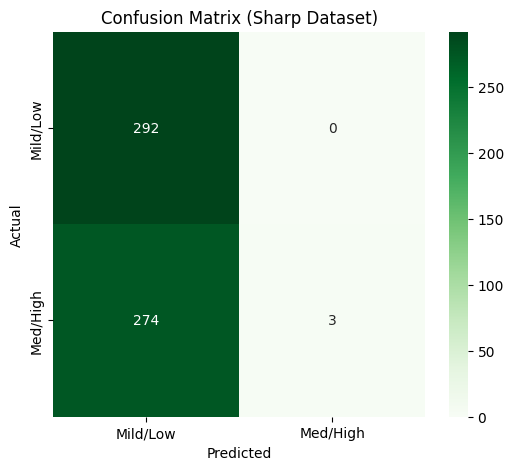


🔥 FINAL SUBJECT-LEVEL ACCURACY (SHARP DATA): 50.00%


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import confusion_matrix, classification_report

# --- 1. DATA SETUP ---
severity_root = Path("/kaggle/working/sharp_dataset")
class_map = {'mild': 0, 'low': 0, 'medium': 1, 'high': 1}

data_list = []
for p in severity_root.glob("*/*"):
    if p.suffix.lower() in ['.jpg', '.png', '.jpeg']:
        label = class_map[p.parent.name]
        # Filename is 'subject-ID-label-side.jpg'
        subject = p.name.split('-')[0]
        data_list.append({'path': str(p), 'label': label, 'subject': subject})

df = pd.DataFrame(data_list)
print(f"✅ Clean Dataset: {len(df)} images surviving.")

# --- 2. THE TOUGH ARCHITECTURE ---
def build_tough_model():
    img_in = layers.Input(shape=(300, 300, 3))
    
    # HEAVY AUGMENTATION
    x = layers.RandomFlip("horizontal")(img_in)
    x = layers.RandomRotation(0.1)(x)
    x = layers.RandomZoom(0.1)(x)
    
    # Backbone (Starting with standard ImageNet weights)
    base = tf.keras.applications.EfficientNetV2B0(
        include_top=False, 
        weights='imagenet', 
        input_tensor=x
    )
    
    x = layers.GlobalAveragePooling2D()(base.output)
    
    # The "Wall of Dropout" to kill overfitting
    x = layers.Dense(256, activation='gelu')(x)
    x = layers.Dropout(0.8)(x) 
    
    out = layers.Dense(2, activation='softmax')(x)
    return models.Model(img_in, out)

# --- 3. EXECUTION (SINGLE SPLIT) ---
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, val_idx = next(sgkf.split(df.path, df.label, groups=df.subject))

def parse_fn(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [300, 300])
    img = tf.cast(img, tf.float32) / 255.0
    return img, tf.one_hot(label, 2)

train_ds = tf.data.Dataset.from_tensor_slices((df.iloc[train_idx].path, df.iloc[train_idx].label)).shuffle(len(train_idx)).map(parse_fn).batch(16).prefetch(2)
val_ds = tf.data.Dataset.from_tensor_slices((df.iloc[val_idx].path, df.iloc[val_idx].label)).map(parse_fn).batch(16).prefetch(2)

model = build_tough_model()
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

print("🚀 Starting Single-Split Training...")
model.fit(train_ds, validation_data=val_ds, epochs=30)

# --- 4. EVALUATION & CONFUSION MATRIX ---
print("\n📊 Evaluating Sharp Model...")
preds = model.predict(val_ds)
y_pred = np.argmax(preds, axis=1)
y_true = df.iloc[val_idx].label.values

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Mild/Low', 'Med/High'], yticklabels=['Mild/Low', 'Med/High'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Sharp Dataset)')
plt.show()

# Subject-Level Consensus
val_results = df.iloc[val_idx].copy()
val_results['pred'] = y_pred

subject_vote = val_results.groupby('subject').agg({
    'label': 'first',
    'pred': lambda x: x.value_counts().index[0]
})

final_acc = (subject_vote['label'] == subject_vote['pred']).mean()
print(f"\n🔥 FINAL SUBJECT-LEVEL ACCURACY (SHARP DATA): {final_acc*100:.2f}%")

2026-01-28 11:29:58.379631: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769599798.591636      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769599798.648498      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769599799.200514      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769599799.200563      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769599799.200567      55 computation_placer.cc:177] computation placer alr

📊 Prepping Sharp Hybrid Data...


I0000 00:00:1769599813.156938      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1769599813.160924      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


✅ Phase 1 Weights Anchored.
🚀 Training on 2464 images. Val on 536 images.
Epoch 1/25


I0000 00:00:1769599829.208434     130 service.cc:152] XLA service 0x7ab2201145f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769599829.208475     130 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1769599829.208480     130 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1769599831.894542     130 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-01-28 11:30:39.146222: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-28 11:30:39.287029: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-28 11:30:40.656935: E external/local_xl

153/154 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5275 - loss: 0.7164

2026-01-28 11:31:09.369980: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-28 11:31:09.505712: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-28 11:31:10.801306: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-28 11:31:10.940751: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


154/154 ━━━━━━━━━━━━━━━━━━━━ 59s 159ms/step - accuracy: 0.5280 - loss: 0.7160 - val_accuracy: 0.3825 - val_loss: 0.8324
Epoch 2/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.6312 - loss: 0.6270 - val_accuracy: 0.4515 - val_loss: 0.8217
Epoch 3/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.6909 - loss: 0.5829 - val_accuracy: 0.4664 - val_loss: 1.0088
Epoch 4/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.7128 - loss: 0.5332 - val_accuracy: 0.4534 - val_loss: 0.8760
Epoch 5/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.7111 - loss: 0.5336 - val_accuracy: 0.4291 - val_loss: 0.9573
Epoch 6/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.7166 - loss: 0.5188 - val_accuracy: 0.4422 - val_loss: 1.0436
Epoch 7/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.7199 - loss: 0.5165 - val_accuracy: 0.4683 - val_loss: 1.0568
Epoch 8/25
154/154 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.7576 - loss: 0.4701 - val_accuracy: 0.4

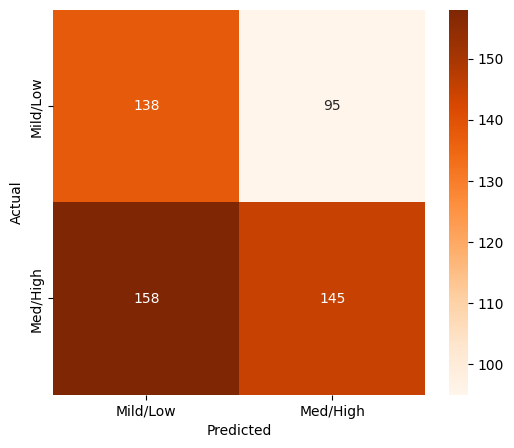


🔥 LOCKED HYBRID SUBJECT ACCURACY: 75.00%


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import confusion_matrix, classification_report

# --- 1. CORE LAYERS (PRESERVED) ---
class EyeballMaskLayer(layers.Layer):
    def __init__(self, radius=135, **kwargs):
        super().__init__(**kwargs)
        self.radius, self.size = radius, 300
    def build(self, input_shape):
        center = self.size // 2
        y, x = np.ogrid[:self.size, :self.size]
        mask_np = (np.sqrt((x - center)**2 + (y - center)**2) <= self.radius).astype(np.float32)
        self.mask = tf.constant(mask_np[:, :, np.newaxis], dtype=tf.float32)
        super().build(input_shape)
    def call(self, inputs): return inputs * self.mask
    def get_config(self):
        config = super().get_config()
        config.update({"radius": self.radius})
        return config

class AttentionPooling(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
    def build(self, input_shape):
        self.q = self.add_weight(name="query", shape=(input_shape[-1], 1), initializer="glorot_uniform")
    def call(self, x):
        scores = tf.nn.softmax(tf.matmul(x, self.q), axis=1)
        return tf.reduce_sum(x * scores, axis=1)

# --- 2. DATA PREPARATION (SHARP + MATH) ---
print("📊 Prepping Sharp Hybrid Data...")
df_math = pd.read_csv('/kaggle/input/eye-features-adaptive-final/eye_features_adaptive_final_2.csv')
df_math['filename'] = df_math['path'].apply(lambda x: x.split('/')[-1])

sharp_root = Path("/kaggle/working/sharp_dataset")
sharp_paths = {p.name: str(p) for p in sharp_root.glob("*/*") if p.suffix.lower() in ['.jpg', '.png']}

# Merge math features with surviving sharp images
df = df_math[df_math['filename'].isin(sharp_paths.keys())].copy()
df['path'] = df['filename'].map(sharp_paths)

class_map = {'mild': 0, 'low': 0, 'medium': 1, 'high': 1}
df['label_num'] = df['label_name'].map(class_map)
math_feats = df[['pi_ratio', 'texture_energy', 'aperture']].values

# --- 3. THE LOCKED HYBRID ARCHITECTURE ---
def build_locked_hybrid():
    img_in = layers.Input(shape=(300, 300, 3), name="image_input")
    math_in = layers.Input(shape=(3,), name="math_input")

    # Image Arm
    v = layers.RandomFlip("horizontal")(img_in)
    v = EyeballMaskLayer(name="mask_layer")(v)
    
    # Load and LOCK Backbone
    base = tf.keras.applications.EfficientNetV2B0(include_top=False, weights=None)
    base._name = "backbone_v2"
    wp = "/kaggle/input/phase1-weight/anatomy_master.weights.h5"
    if os.path.exists(wp):
        base.load_weights(wp)
        print("✅ Phase 1 Weights Anchored.")
    
    base.trainable = False # PREVENT IDENTITY MEMORIZATION

    features = base(v)
    f_h, f_w, channels = features.shape[1], features.shape[2], features.shape[3]
    x_seq = layers.Reshape((f_h * f_w, channels))(features)
    vision_signal = AttentionPooling()(x_seq)

    # Math Arm
    m = layers.Dense(64, activation='gelu')(math_in)
    m = layers.LayerNormalization()(m)

    # Fusion
    combined = layers.Concatenate()([vision_signal, m])
    z = layers.Dense(128, activation='gelu')(combined)
    z = layers.Dropout(0.6)(z) # High dropout for safety
    out = layers.Dense(2, activation='softmax', name="severity_output")(z)

    return models.Model(inputs=[img_in, math_in], outputs=out)

# --- 4. EXECUTION ---
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, val_idx = next(sgkf.split(df.path, df.label_num, groups=df.subject))

def parse_hybrid(path, math_data, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [300, 300])
    img = tf.cast(img, tf.float32) / 255.0
    return {"image_input": img, "math_input": math_data}, tf.one_hot(label, 2)

train_ds = tf.data.Dataset.from_tensor_slices((df.iloc[train_idx].path, math_feats[train_idx], df.iloc[train_idx].label_num)).shuffle(len(train_idx)).map(parse_hybrid).batch(16).prefetch(2)
val_ds = tf.data.Dataset.from_tensor_slices((df.iloc[val_idx].path, math_feats[val_idx], df.iloc[val_idx].label_num)).map(parse_hybrid).batch(16).prefetch(2)

model = build_locked_hybrid()
model.compile(optimizer=tf.keras.optimizers.Adam(2e-4), loss='categorical_crossentropy', metrics=['accuracy'])

print(f"🚀 Training on {len(df.iloc[train_idx])} images. Val on {len(df.iloc[val_idx])} images.")
model.fit(train_ds, validation_data=val_ds, epochs=25)

# --- 5. EVALUATION ---
print("\n📊 Final Analysis (Subject Vote)...")
preds = model.predict(val_ds)
y_pred = np.argmax(preds, axis=1)
y_true = df.iloc[val_idx].label_num.values

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=['Mild/Low', 'Med/High'], yticklabels=['Mild/Low', 'Med/High'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Consensus Vote
res_df = df.iloc[val_idx].copy()
res_df['pred'] = y_pred
subject_res = res_df.groupby('subject').agg({'label_num': 'first', 'pred': lambda x: x.value_counts().index[0]})
subject_acc = (subject_res['label_num'] == subject_res['pred']).mean()

print(f"\n🔥 LOCKED HYBRID SUBJECT ACCURACY: {subject_acc*100:.2f}%")

In [3]:
import shutil
import os

# Define the folder you want to zip and the name of the output zip file
folder_to_zip = '/kaggle/working/sharp_dataset'
output_zip = '/kaggle/working/sharp_dataset'

# Create the zip file
if os.path.exists(folder_to_zip):
    shutil.make_archive(output_zip, 'zip', folder_to_zip)
    print(f"✅ Success! Your dataset has been zipped: {output_zip}.zip")
    print("You can now download it from the 'Output' section on the right sidebar.")
else:
    print(f"❌ Error: The folder {folder_to_zip} was not found. Did the cropping script finish?")

✅ Success! Your dataset has been zipped: /kaggle/working/sharp_dataset.zip
You can now download it from the 'Output' section on the right sidebar.


🚀 Starting Master Hybrid Training...
Epoch 1/40


E0000 00:00:1769603764.456683      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


200/200 ━━━━━━━━━━━━━━━━━━━━ 99s 276ms/step - accuracy: 0.5827 - auc: 0.6120 - loss: 0.6782 - val_accuracy: 0.3975 - val_auc: 0.4035 - val_loss: 0.8819
Epoch 2/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 52s 261ms/step - accuracy: 0.6443 - auc: 0.7226 - loss: 0.6251 - val_accuracy: 0.4538 - val_auc: 0.4369 - val_loss: 0.8139
Epoch 3/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 52s 260ms/step - accuracy: 0.7251 - auc: 0.8045 - loss: 0.5691 - val_accuracy: 0.5550 - val_auc: 0.5562 - val_loss: 0.7428
Epoch 4/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 52s 261ms/step - accuracy: 0.7684 - auc: 0.8486 - loss: 0.5311 - val_accuracy: 0.5025 - val_auc: 0.5227 - val_loss: 0.7288
Epoch 5/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 52s 261ms/step - accuracy: 0.7707 - auc: 0.8611 - loss: 0.5154 - val_accuracy: 0.5425 - val_auc: 0.5565 - val_loss: 0.8321
Epoch 6/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 52s 260ms/step - accuracy: 0.7995 - auc: 0.8868 - loss: 0.4866 - val_accuracy: 0.5612 - val_auc: 0.5798 - val_loss: 0.7440
Epoch 7/40
200/200 ━━━━━━━━━━━━━━

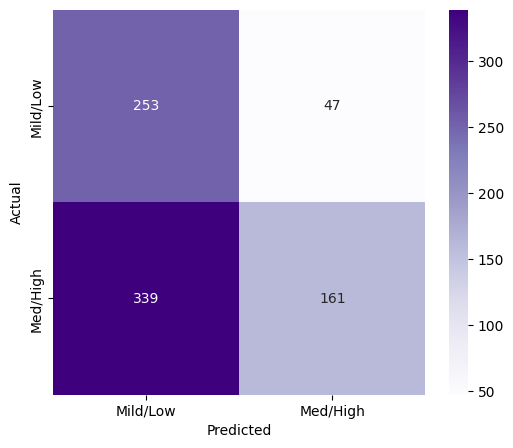


🔥 MASTER HYBRID SUBJECT ACCURACY: 50.00%


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import confusion_matrix, classification_report

# --- 1. CORE COMPONENTS ---
class EyeballMaskLayer(layers.Layer):
    def __init__(self, radius=135, **kwargs):
        super().__init__(**kwargs)
        self.radius, self.size = radius, 300
    def build(self, input_shape):
        center = self.size // 2
        y, x = np.ogrid[:self.size, :self.size]
        mask_np = (np.sqrt((x - center)**2 + (y - center)**2) <= self.radius).astype(np.float32)
        self.mask = tf.constant(mask_np[:, :, np.newaxis], dtype=tf.float32)
        super().build(input_shape)
    def call(self, inputs): return inputs * self.mask

class SpatialAttention(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.conv = layers.Conv1D(1, kernel_size=3, padding='same', activation='sigmoid')
    def build(self, input_shape):
        self.conv.build((None, input_shape[1], 2)) 
        super().build(input_shape)
    def call(self, x):
        avg_p = tf.reduce_mean(x, axis=-1, keepdims=True)
        max_p = tf.reduce_max(x, axis=-1, keepdims=True)
        return x * self.conv(tf.concat([avg_p, max_p], axis=-1))

class PositionalEmbedding(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches, self.projection_dim = num_patches, projection_dim
        self.pos_emb = self.add_weight(name="pos_embedding", shape=(1, num_patches, projection_dim), initializer="zeros")
    def call(self, x): return x + self.pos_emb

class ProgressiveUnfreezing(tf.keras.callbacks.Callback):
    def __init__(self, backbone, start_epoch=15, unfreeze_per_epoch=10):
        super().__init__()
        self.backbone = backbone
        self.start_epoch = start_epoch
        self.unfreeze_per_epoch = unfreeze_per_epoch
    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.start_epoch: return
        total_layers = len(self.backbone.layers)
        unfreeze_count = (epoch - self.start_epoch + 1) * self.unfreeze_per_epoch
        frozen_until = max(20, total_layers - 50 - unfreeze_count)
        self.backbone.trainable = True
        for i, layer in enumerate(self.backbone.layers):
            if i < 20 or isinstance(layer, layers.BatchNormalization) or i >= (total_layers - 50):
                layer.trainable = False
            elif i >= frozen_until:
                layer.trainable = True
            else:
                layer.trainable = False

# --- 2. DATA PREP ---
df_math = pd.read_csv('/kaggle/input/eye-features-adaptive-final/eye_features_adaptive_final_2.csv')
df_math['filename'] = df_math['path'].apply(lambda x: x.split('/')[-1])
sharp_root = Path("/kaggle/input/et-cropped-dataset-second")
sharp_paths = {p.name: str(p) for p in sharp_root.glob("*/*") if p.suffix.lower() in ['.jpg', '.png']}
df = df_math[df_math['filename'].isin(sharp_paths.keys())].copy()
df['path'] = df['filename'].map(sharp_paths)
class_map = {'mild': 0, 'low': 0, 'medium': 1, 'high': 1}
df['label_num'] = df['label_name'].map(class_map)
math_feats = df[['pi_ratio', 'texture_energy', 'aperture']].values

# --- 3. ARCHITECTURE ---
def build_master_hybrid():
    img_in = layers.Input(shape=(300, 300, 3), name="image_input")
    math_in = layers.Input(shape=(3,), name="math_input")
    
    # Vision Arm
    v = layers.RandomFlip("horizontal")(img_in)
    v = layers.RandomRotation(0.05)(v)
    v = layers.RandomZoom(0.1)(v)
    v = EyeballMaskLayer()(v)
    
    base = tf.keras.applications.EfficientNetV2B0(include_top=False, weights='imagenet')
    base._name = "backbone_v2"
    v = base(v)
    
    f_h, f_w, channels = v.shape[1], v.shape[2], v.shape[3]
    v = layers.Reshape((f_h * f_w, channels))(v)
    v = SpatialAttention()(v)
    v = PositionalEmbedding(f_h * f_w, channels)(v)
    
    # Transformer Block
    res = v
    v = layers.LayerNormalization()(v)
    v = layers.MultiHeadAttention(num_heads=4, key_dim=32, dropout=0.4)(v, v)
    v = layers.Add()([res, v])
    v = layers.GlobalAveragePooling1D()(v)
    
    # Math Arm + Fusion
    m = layers.Dense(64, activation='gelu')(math_in)
    m = layers.LayerNormalization()(m)
    
    combined = layers.Concatenate()([v, m])
    z = layers.Dense(256, activation='gelu')(combined)
    z = layers.Dropout(0.5)(z)
    out = layers.Dense(2, activation='softmax', name="severity_output")(z)
    
    return models.Model(inputs=[img_in, math_in], outputs=out), base

# --- 4. EXECUTION ---
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, val_idx = next(sgkf.split(df.path, df.label_num, groups=df.subject))

def parse_hybrid(path, math_data, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [300, 300])
    img = tf.cast(img, tf.float32) / 255.0
    return {"image_input": img, "math_input": math_data}, tf.one_hot(label, 2)

train_ds = tf.data.Dataset.from_tensor_slices((df.iloc[train_idx].path, math_feats[train_idx], df.iloc[train_idx].label_num)).shuffle(len(train_idx)).map(parse_hybrid).batch(16).prefetch(2)
val_ds = tf.data.Dataset.from_tensor_slices((df.iloc[val_idx].path, math_feats[val_idx], df.iloc[val_idx].label_num)).map(parse_hybrid).batch(16).prefetch(2)

model, backbone = build_master_hybrid()
model.compile(optimizer=tf.keras.optimizers.Adam(3e-5), loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1), metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

print("🚀 Starting Master Hybrid Training...")
model.fit(train_ds, validation_data=val_ds, epochs=40, callbacks=[ProgressiveUnfreezing(backbone)])

# --- 5. EVALUATION ---
preds = model.predict(val_ds)
y_pred = np.argmax(preds, axis=1)
y_true = df.iloc[val_idx].label_num.values

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['Mild/Low', 'Med/High'], yticklabels=['Mild/Low', 'Med/High'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Consensus Subject Vote
res_df = df.iloc[val_idx].copy()
res_df['pred'] = y_pred
subject_res = res_df.groupby('subject').agg({'label_num': 'first', 'pred': lambda x: x.value_counts().index[0]})
print(f"\n🔥 MASTER HYBRID SUBJECT ACCURACY: {(subject_res['label_num'] == subject_res['pred']).mean()*100:.2f}%")

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import pandas as pd
import numpy as np
import os
from pathlib import Path
from sklearn.model_selection import StratifiedGroupKFold

# --- 1. THE RECOVERY MODEL (MobileNetV2 + Math Focus) ---
class EyeballMaskLayer(layers.Layer):
    def __init__(self, radius=120, **kwargs): # Tightened mask
        super().__init__(**kwargs)
        self.radius, self.size = radius, 300
    def build(self, input_shape):
        center = self.size // 2
        y, x = np.ogrid[:self.size, :self.size]
        mask_np = (np.sqrt((x - center)**2 + (y - center)**2) <= self.radius).astype(np.float32)
        self.mask = tf.constant(mask_np[:, :, np.newaxis], dtype=tf.float32)
        super().build(input_shape)
    def call(self, inputs): return inputs * self.mask

def build_recovery_model():
    img_in = layers.Input(shape=(300, 300, 3), name="image_input")
    math_in = layers.Input(shape=(3,), name="math_input")
    
    # Vision: Forced focus
    v = layers.RandomFlip("horizontal")(img_in)
    v = EyeballMaskLayer()(v)
    
    # MobileNetV2: Lighter backbone to prevent memorization
    base = tf.keras.applications.MobileNetV2(include_top=False, weights='imagenet')
    base.trainable = False # Keep frozen to act as a generic feature extractor
    v = base(v)
    v = layers.GlobalAveragePooling2D()(v)
    
    # Math Arm: Boosted volume
    m = layers.Dense(128, activation='gelu')(math_in)
    m = layers.LayerNormalization()(m)
    
    combined = layers.Concatenate()([v, m])
    
    # The "Wall of Resistance"
    z = layers.Dense(512, activation='gelu')(combined)
    z = layers.Dropout(0.85)(z) # Brutal dropout to kill identity patterns
    out = layers.Dense(2, activation='softmax', name="severity_output")(z)
    
    return models.Model(inputs=[img_in, math_in], outputs=out)

# --- 2. DATA LOAD & SPLIT ---
df_math = pd.read_csv('/kaggle/input/eye-features-adaptive-final/eye_features_adaptive_final_2.csv')
df_math['filename'] = df_math['path'].apply(lambda x: x.split('/')[-1])
sharp_root = Path("/kaggle/input/autism-sharp-dataset")
sharp_paths = {p.name: str(p) for p in sharp_root.glob("*/*") if p.suffix.lower() in ['.jpg', '.png']}
df = df_math[df_math['filename'].isin(sharp_paths.keys())].copy()
df['path'] = df['filename'].map(sharp_paths)
class_map = {'mild': 0, 'low': 0, 'medium': 1, 'high': 1}
df['label_num'] = df['label_name'].map(class_map)
math_feats = df[['pi_ratio', 'texture_energy', 'aperture']].values

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, val_idx = next(sgkf.split(df.path, df.label_num, groups=df.subject))

def parse_fn(path, math_data, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [300, 300])
    img = tf.cast(img, tf.float32) / 255.0
    return {"image_input": img, "math_input": math_data}, tf.one_hot(label, 2)

train_ds = tf.data.Dataset.from_tensor_slices((df.iloc[train_idx].path, math_feats[train_idx], df.iloc[train_idx].label_num)).shuffle(len(train_idx)).map(parse_fn).batch(32).prefetch(2)
val_ds = tf.data.Dataset.from_tensor_slices((df.iloc[val_idx].path, math_feats[val_idx], df.iloc[val_idx].label_num)).map(parse_fn).batch(32).prefetch(2)

# --- 3. TRAIN ---
model = build_recovery_model()
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

print("🚀 Starting Recovery Training (Starvation Mode)...")
model.fit(train_ds, validation_data=val_ds, epochs=30)

2026-01-28 13:16:51.575831: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769606211.750164      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769606211.801564      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769606212.196256      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769606212.196301      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769606212.196304      55 computation_placer.cc:177] computation placer alr

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
🚀 Starting Recovery Training (Starvation Mode)...
Epoch 1/30


I0000 00:00:1769606233.024144     125 service.cc:152] XLA service 0x78bc582136f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769606233.024183     125 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1769606233.024190     125 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1769606234.276161     125 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-01-28 13:17:23.651485: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-28 13:17:23.788193: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1769606246.891114     125 device_co

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.4762 - loss: 1.1175

2026-01-28 13:17:48.623898: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-28 13:17:48.761052: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


77/77 ━━━━━━━━━━━━━━━━━━━━ 45s 305ms/step - accuracy: 0.4764 - loss: 1.1155 - val_accuracy: 0.4739 - val_loss: 0.7422
Epoch 2/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.5636 - loss: 0.7316 - val_accuracy: 0.4739 - val_loss: 0.7491
Epoch 3/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.6107 - loss: 0.6690 - val_accuracy: 0.4701 - val_loss: 0.7827
Epoch 4/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.6233 - loss: 0.6484 - val_accuracy: 0.4701 - val_loss: 0.8241
Epoch 5/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.6386 - loss: 0.6307 - val_accuracy: 0.4907 - val_loss: 0.7795
Epoch 6/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.6372 - loss: 0.6288 - val_accuracy: 0.4776 - val_loss: 0.8210
Epoch 7/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.6798 - loss: 0.6011 - val_accuracy: 0.4851 - val_loss: 0.7961
Epoch 8/30
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.6766 - loss: 0.5967 - val_accuracy: 0.4795 - val_loss: 

In [2]:
# --- RUN THIS IMMEDIATELY ---
print("\n📊 Evaluating Recovery Model (Subject Vote)...")
preds = model.predict(val_ds)
y_pred = np.argmax(preds, axis=1)
y_true = df.iloc[val_idx].label_num.values

res_df = df.iloc[val_idx].copy()
res_df['pred'] = y_pred

# Majority Vote per child
subject_res = res_df.groupby('subject').agg({
    'label_num': 'first', 
    'pred': lambda x: x.value_counts().index[0]
})

subject_acc = (subject_res['label_num'] == subject_res['pred']).mean()
print(f"🔥 RECOVERY SUBJECT ACCURACY: {subject_acc*100:.2f}%")


📊 Evaluating Recovery Model (Subject Vote)...
17/17 ━━━━━━━━━━━━━━━━━━━━ 12s 401ms/step
🔥 RECOVERY SUBJECT ACCURACY: 62.50%


In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Prep Pure Tabular Data
X_train = math_feats[train_idx]
y_train = df.iloc[train_idx].label_num.values

X_val = math_feats[val_idx]
y_val = df.iloc[val_idx].label_num.values

# 2. Train a "Logic-Based" Model
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

# 3. Evaluate
rf_preds = rf.predict(X_val)
rf_acc = accuracy_score(y_val, rf_preds)

# 4. Subject Vote for Math
val_math_df = df.iloc[val_idx].copy()
val_math_df['rf_pred'] = rf_preds
math_subject_res = val_math_df.groupby('subject').agg({
    'label_num': 'first', 
    'rf_pred': lambda x: x.value_counts().index[0]
})
math_subject_acc = (math_subject_res['label_num'] == math_subject_res['rf_pred']).mean()

print(f"📉 PURE IMAGE-FREE ACCURACY: {rf_acc*100:.2f}%")
print(f"🔥 PURE MATH SUBJECT ACCURACY: {math_subject_acc*100:.2f}%")

📉 PURE IMAGE-FREE ACCURACY: 45.90%
🔥 PURE MATH SUBJECT ACCURACY: 37.50%
